# Ground Truth 기반 벡터DB 검색 성능 평가
- **Precision@1**: Top-1 결과가 relevant인 비율
- **Recall@5**: Top-5 안에 relevant_image가 포함된 비율

In [ ]:
import csv
import os
from collections import defaultdict
import chromadb
import pandas as pd

# 경로 설정
GT_CSV = r"C:\Users\playdata2\Desktop\SKN_AI_20\SKN20-FINAL-2TEAM(vb1)\design\ground_truth\ground_truth_task2_filtered.csv"
CHROMA_DB = r"C:\Users\playdata2\Desktop\SKN_AI_20\SKN20-FINAL-2TEAM(vb1)\design\chroma_db"
IMAGE_DIR = r"C:\Users\playdata2\Desktop\SKN_AI_20\SKN20-FINAL-2TEAM(vb1)\design\data\images(21,895개)"

In [10]:
# 이미지 파일 목록을 미리 로드
image_files = set(os.listdir(IMAGE_DIR))
print(f"이미지 파일 수: {len(image_files)}")

def image_filename_to_db_id(filename):
    stem = os.path.splitext(filename)[0]
    last_us = stem.rfind('_')
    design_id = stem[:last_us]
    img_num = stem[last_us + 1:]
    return f"{design_id}-IMG-{int(img_num)}"


def db_id_to_image_filename(db_id):
    """'3020250000208-09-01-0-IMG-0' -> '3020250000208-09-01-0_000.jpg'"""
    parts = db_id.split("-IMG-")
    if len(parts) != 2:
        return None
    design_id = parts[0]
    prefix = f"{design_id}_"
    for fname in image_files:
        if fname.startswith(prefix):
            return fname
    return None


이미지 파일 수: 20778


## 1. Ground Truth 로드

In [3]:
with open(GT_CSV, encoding="utf-8-sig") as f:
    reader = csv.DictReader(f)
    gt_rows = list(reader)

# query_image별 relevant_image 그룹핑
query_relevants = defaultdict(set)
query_types = {}
for row in gt_rows:
    q = row["query_image"]
    r = row["relevant_image"]
    query_relevants[q].add(r)
    query_types[q] = row["similarity_type"]

print(f"Ground Truth 로드: {len(gt_rows)}쌍, 고유 query: {len(query_relevants)}개")

Ground Truth 로드: 16쌍, 고유 query: 16개


## 2. ChromaDB 연결 & ID 매핑 구축

In [7]:
client = chromadb.PersistentClient(path=CHROMA_DB)
collection = client.get_collection(name="design")
print(f"ChromaDB 컬렉션 '{collection.name}' 로드: {collection.count()}개 벡터")

# DB ID -> 이미지 파일명 역매핑
all_ids = collection.get(include=[])["ids"]
dbid_to_filename = {}
for db_id in all_ids:
    fname = db_id_to_image_filename(db_id)
    if fname:
        dbid_to_filename[db_id] = fname

print(f"DB ID -> 파일명 매핑: {len(dbid_to_filename)}개")

ChromaDB 컬렉션 'design' 로드: 21801개 벡터
DB ID -> 파일명 매핑: 20681개


## 3. 쿼리별 검색 & 평가

In [11]:
# 디버깅: 첫 3개 쿼리의 변환 결과 vs 실제 DB ID 비교
sample_queries = list(query_relevants.keys())[:3]

for q in sample_queries:
    db_id = image_filename_to_db_id(q)
    print(f"파일명: {q}")
    print(f"변환된 DB ID: {db_id}")
    
    # 이 ID가 DB에 있는지 확인
    try:
        result = collection.get(ids=[db_id], include=[])
        print(f"DB 조회: {'있음' if result['ids'] else '없음'}")
    except Exception as e:
        print(f"DB 조회 실패: {e}")
    
    print()

# 실제 DB에 저장된 ID 샘플 5개 출력
print("=" * 50)
print("실제 DB ID 샘플 5개:")
for db_id in all_ids[:5]:
    print(f"  {db_id}")


파일명: 3020250019104-api_xml-0_000.jpg
변환된 DB ID: 3020250019104-api_xml-0-IMG-0
DB 조회: 있음

파일명: 3020170036338-api_xml-0_000.jpg
변환된 DB ID: 3020170036338-api_xml-0-IMG-0
DB 조회: 있음

파일명: 3020170010907-api_xml-0_000.jpg
변환된 DB ID: 3020170010907-api_xml-0-IMG-0
DB 조회: 있음

실제 DB ID 샘플 5개:
  3020180025466-api_xml-1-IMG-1
  3020120015713-api_xml-1-IMG-1
  3020220050756-api_xml-0-IMG-0
  3020210026507-api_xml-2-IMG-2
  3020190011820-api_xml-2-IMG-2


In [12]:
K = 5
results_table = []
precision1_hits = 0
recall5_sum = 0.0
total_queries = 0
skipped = 0

for query_img, relevant_set in query_relevants.items():
    query_db_id = image_filename_to_db_id(query_img)

    # 쿼리 임베딩 가져오기
    try:
        query_data = collection.get(ids=[query_db_id], include=["embeddings"])
    except Exception:
        skipped += 1
        continue

    if query_data["embeddings"] is None or len(query_data["embeddings"]) == 0:
        skipped += 1
        continue

    query_embedding = query_data["embeddings"][0]

    # Top-6개 검색 (자기 자신이 Top-1에 나올 수 있으므로 K+1=6개 가져옴)
    search_results = collection.query(
        query_embeddings=[query_embedding],
        n_results=K + 1,  # 6개
    )

    # 결과에서 자기 자신(query) 제외하고 상위 5개만 남김
    # 예: 검색결과 [자신, A, B, C, D, E] → [A, B, C, D, E]
    retrieved_ids = [
        rid for rid in search_results["ids"][0] if rid != query_db_id
    ][:K]  # 최대 5개

    # 위와 같은 방식으로 거리값도 자기 자신 제외하고 수집
    retrieved_distances = []
    for i, rid in enumerate(search_results["ids"][0]):
        if rid != query_db_id and len(retrieved_distances) < K:
            retrieved_distances.append(search_results["distances"][0][i])


    # DB ID -> 파일명 변환
    retrieved_filenames = [dbid_to_filename.get(rid, rid) for rid in retrieved_ids]

    # Precision@1
    p1_hit = 1 if retrieved_filenames and retrieved_filenames[0] in relevant_set else 0
    precision1_hits += p1_hit

    # Recall@5
    hits_in_top5 = sum(1 for fname in retrieved_filenames if fname in relevant_set)
    recall5 = hits_in_top5 / len(relevant_set)
    recall5_sum += recall5

    total_queries += 1

    results_table.append({
        "query": query_img,
        "type": query_types[query_img],
        "n_relevant": len(relevant_set),
        "P@1": p1_hit,
        "hits@5": hits_in_top5,
        "R@5": recall5,
        "top5": retrieved_filenames,
        "top5_dist": retrieved_distances,
    })

print(f"평가 완료: {total_queries}개 쿼리, 건너뜀: {skipped}개")

평가 완료: 14개 쿼리, 건너뜀: 2개


In [16]:
for query_img in query_relevants.keys():
    db_id = image_filename_to_db_id(query_img)
    try:
        result = collection.get(ids=[db_id], include=["embeddings"])
        if result["embeddings"] is None or len(result["embeddings"]) == 0:
            print(f"[임베딩 없음] {query_img} → {db_id}")
    except Exception as e:
        print(f"[ID 없음] {query_img} → {db_id} | {e}")


[임베딩 없음] 3020150029545-api_xml-0_11.jpg → 3020150029545-api_xml-0-IMG-11
[임베딩 없음] 3020140037690-api_xml-0_11.jpg → 3020140037690-api_xml-0-IMG-11


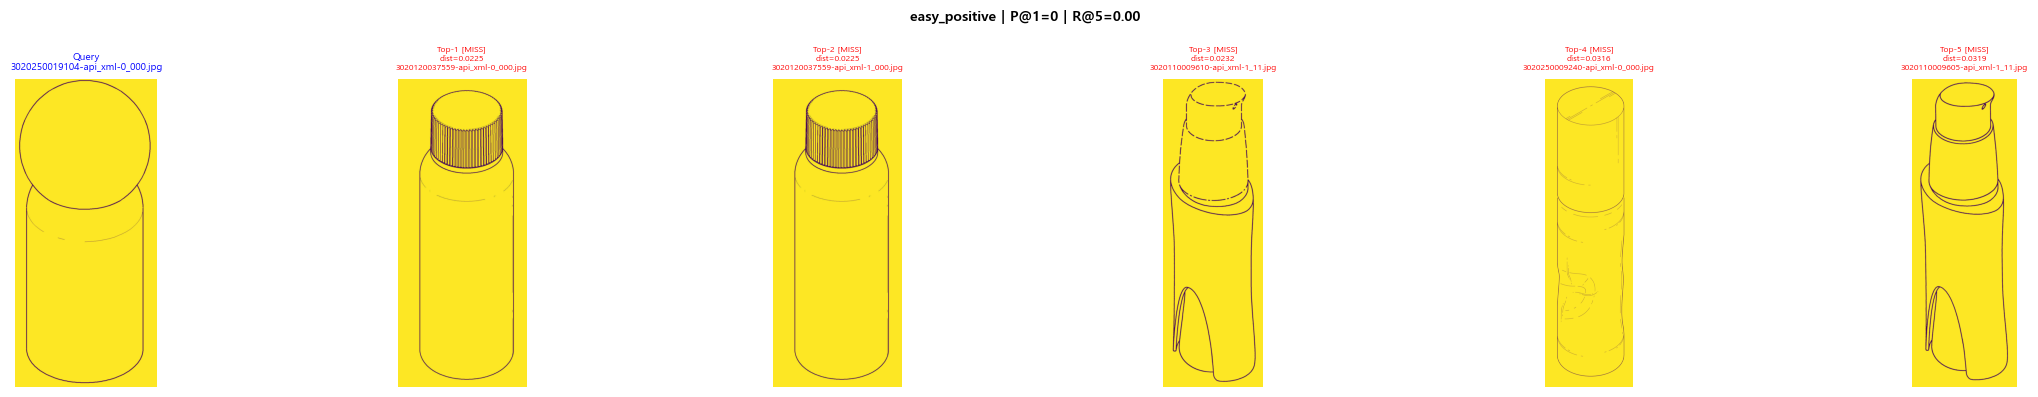

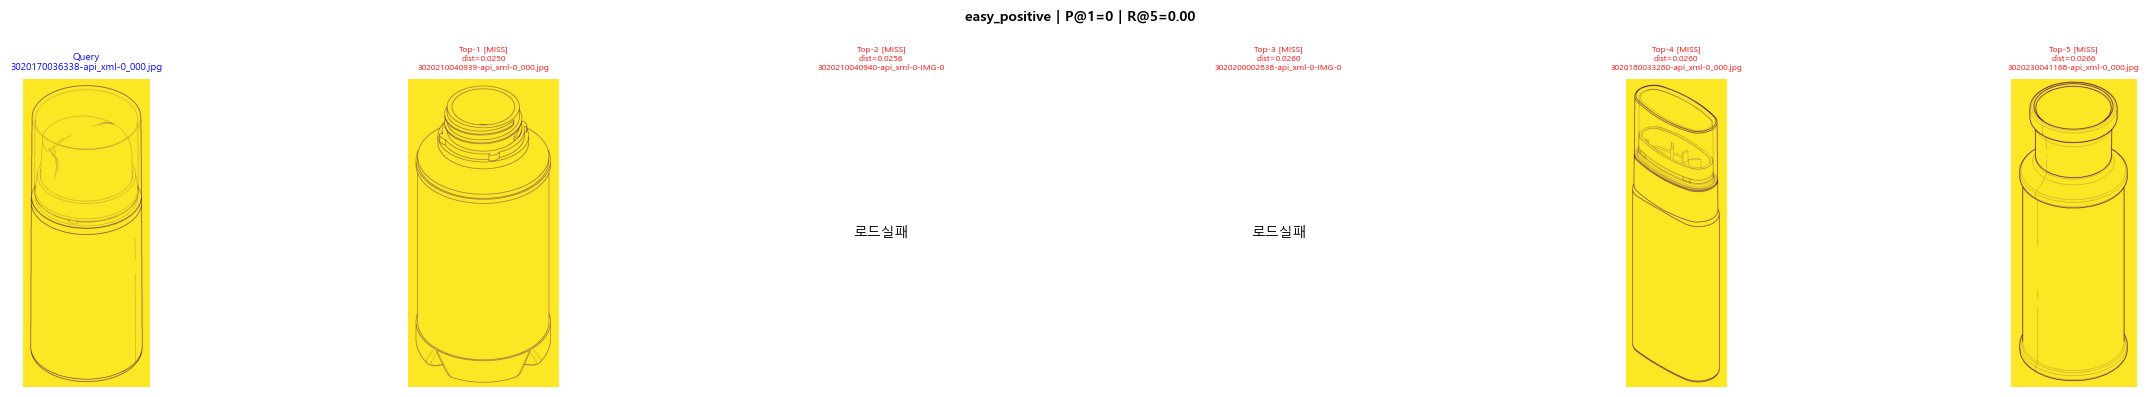

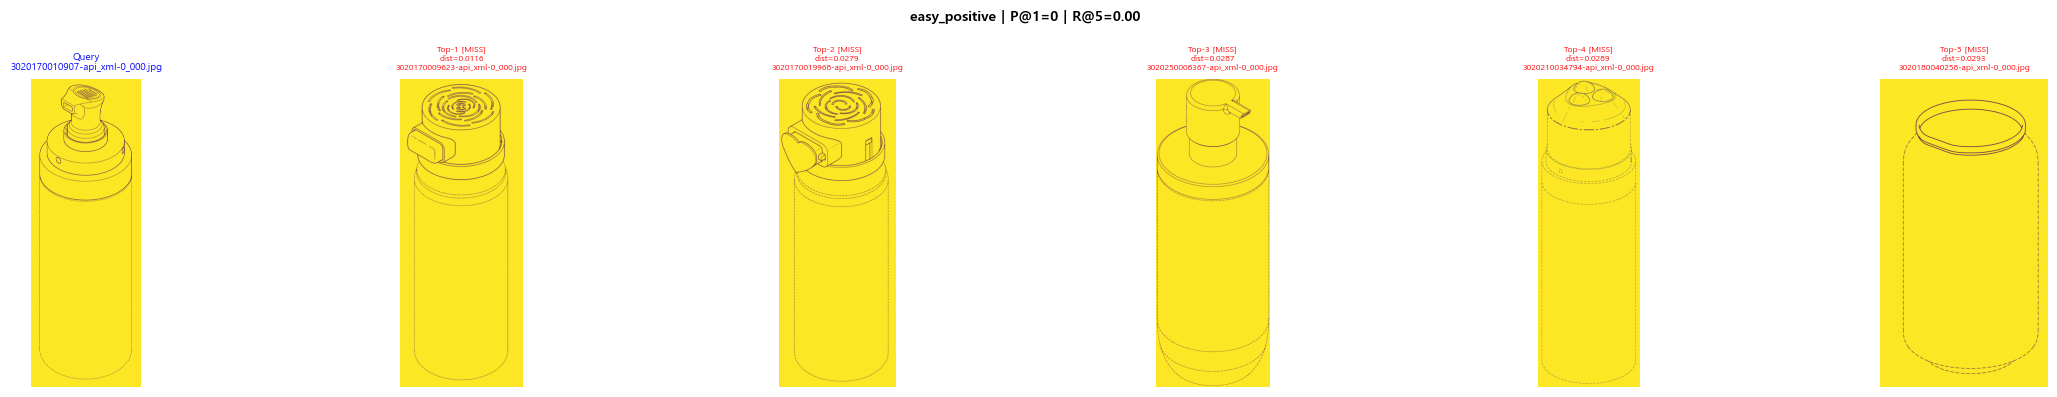

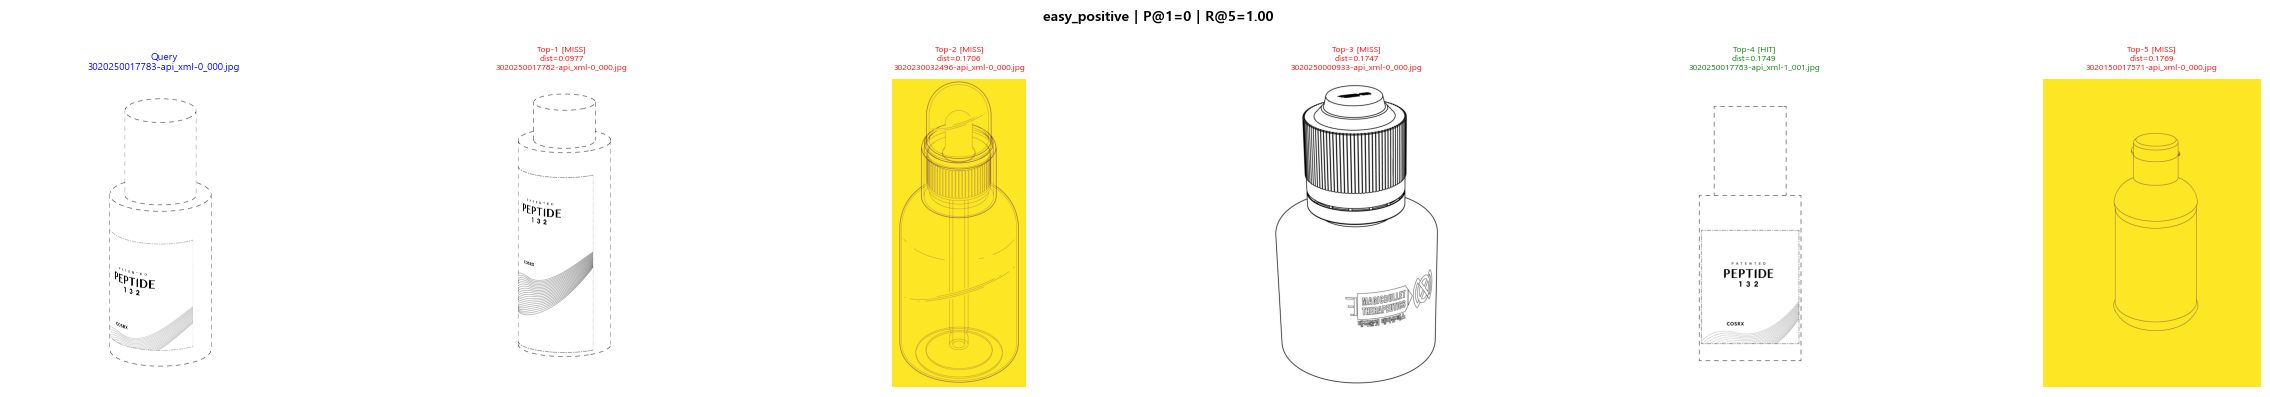

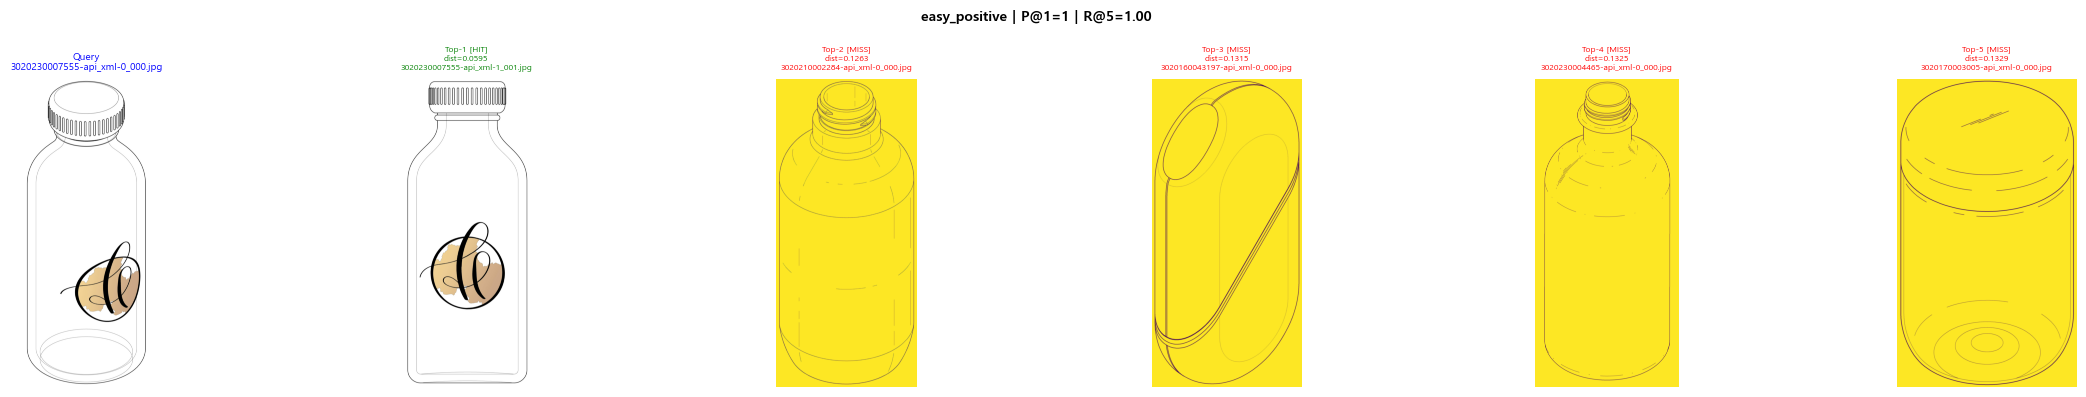

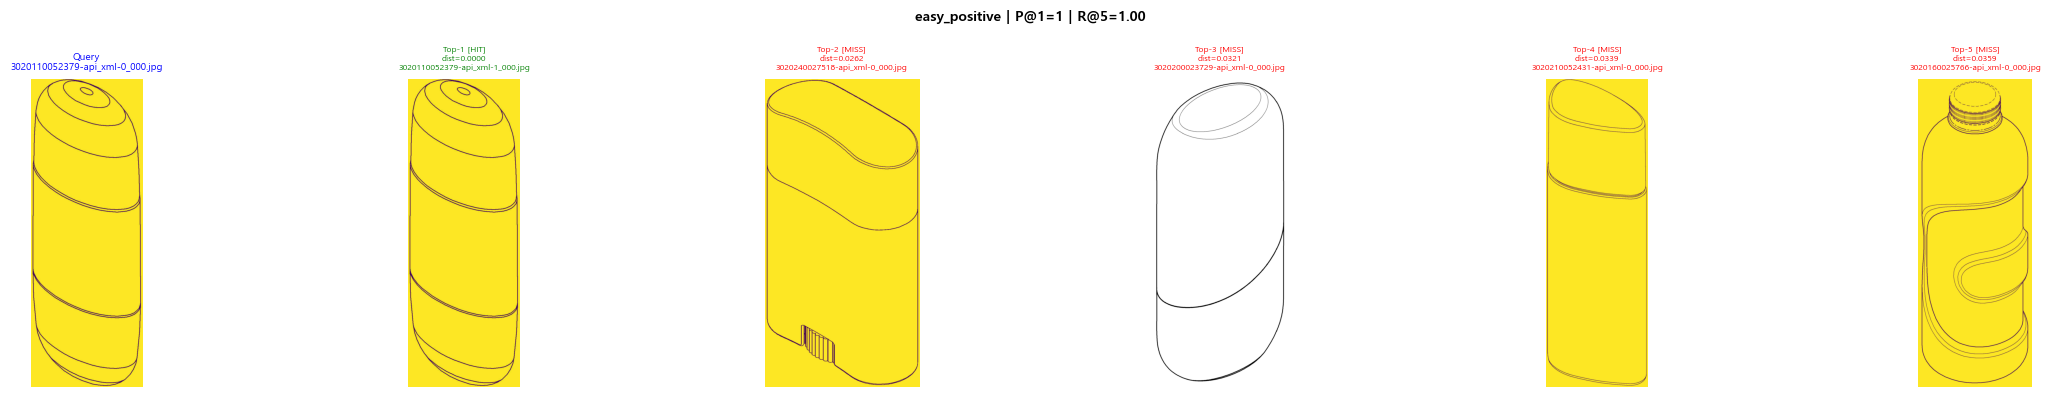

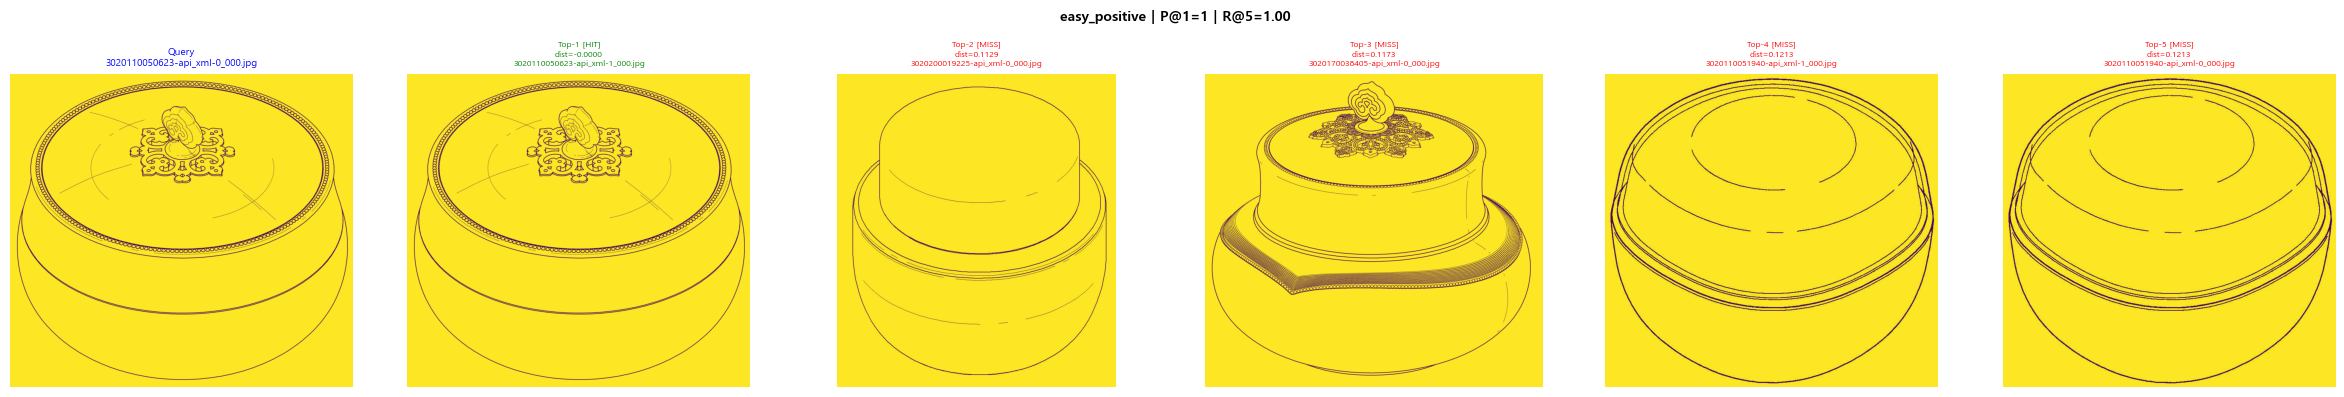

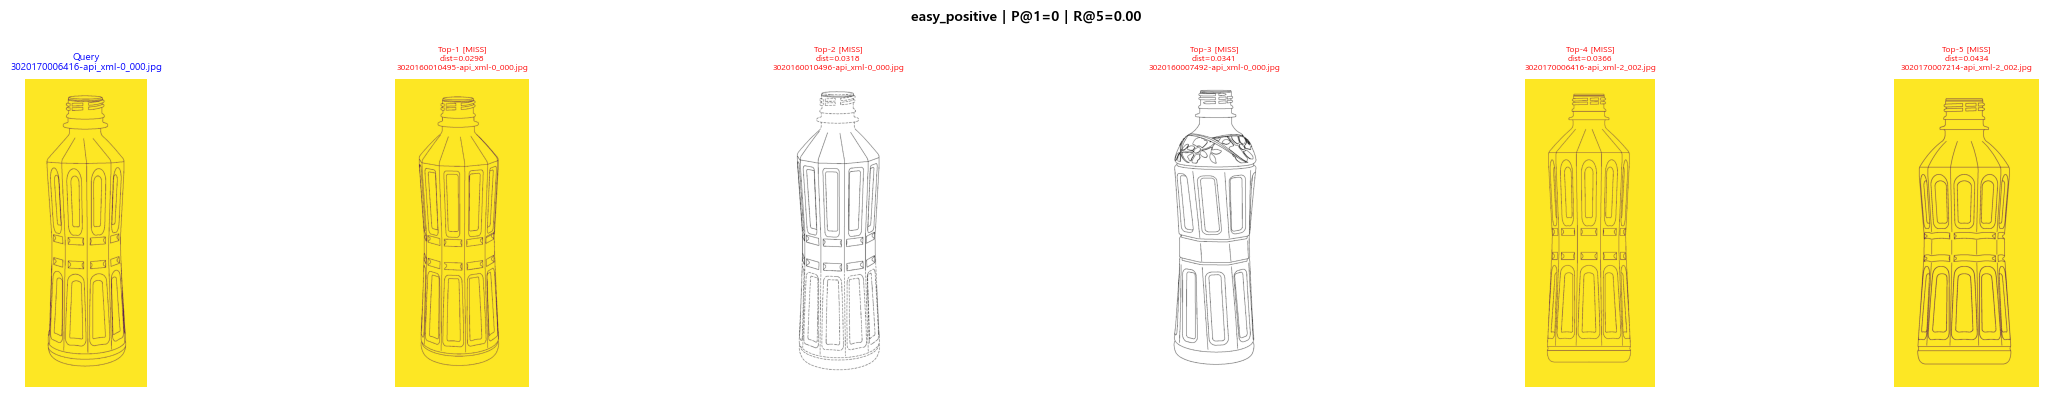

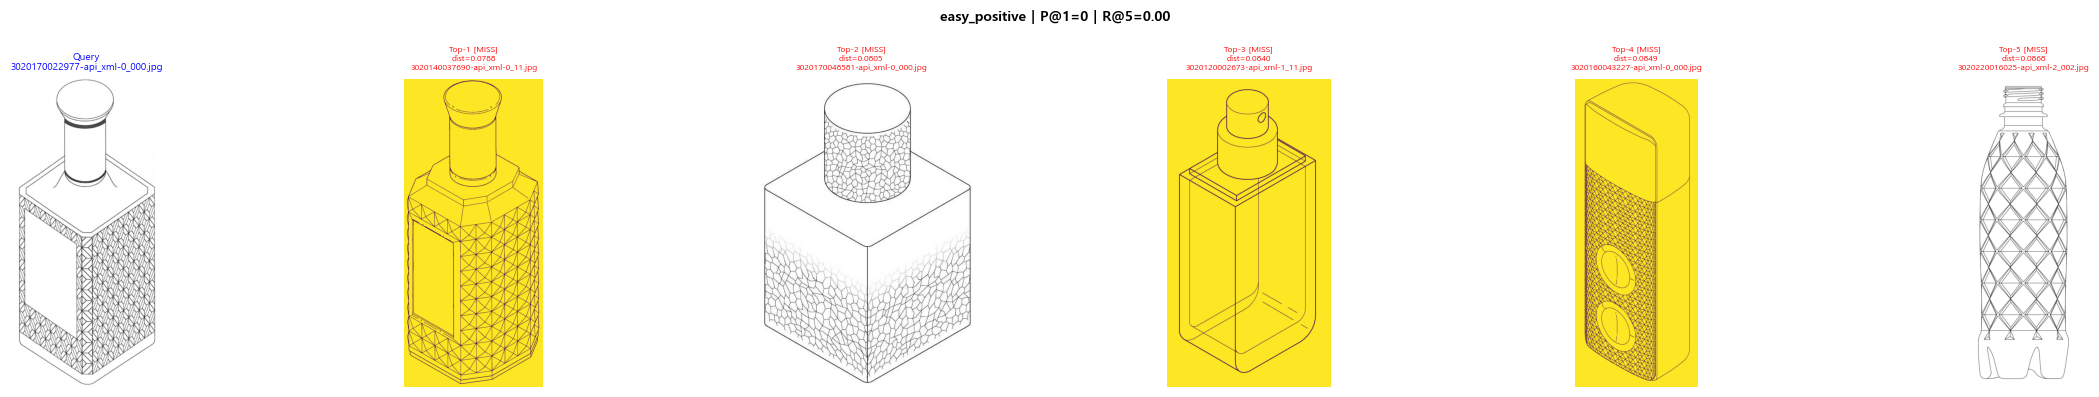

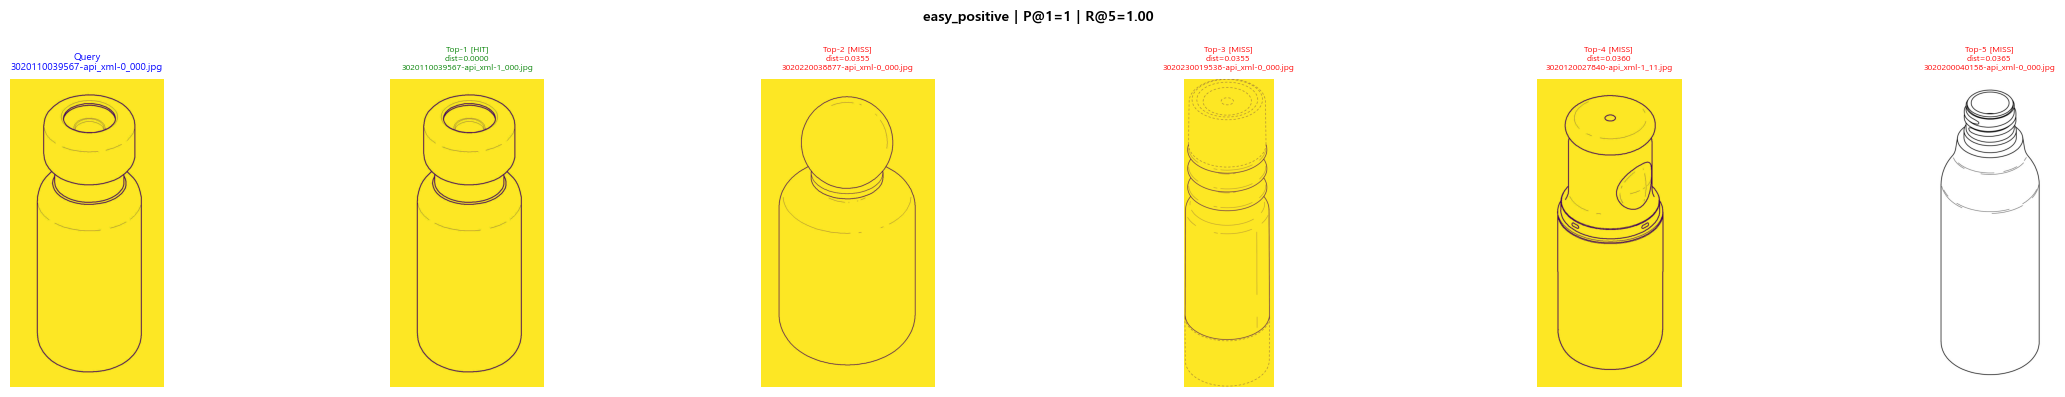

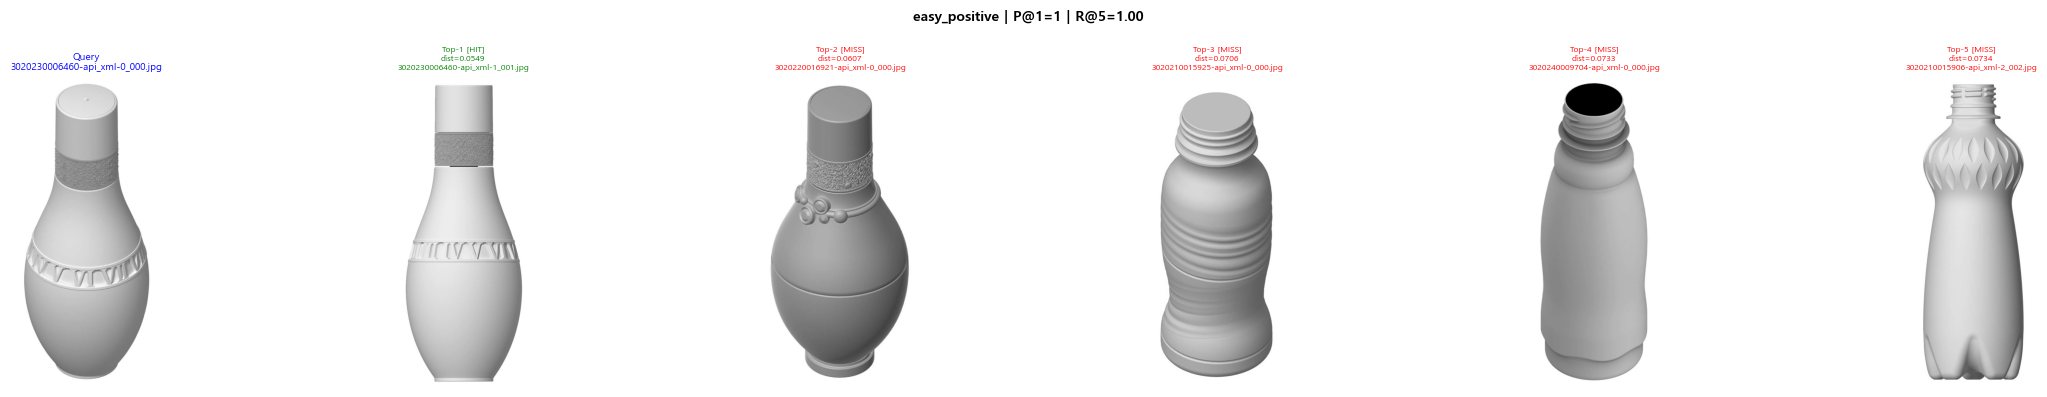

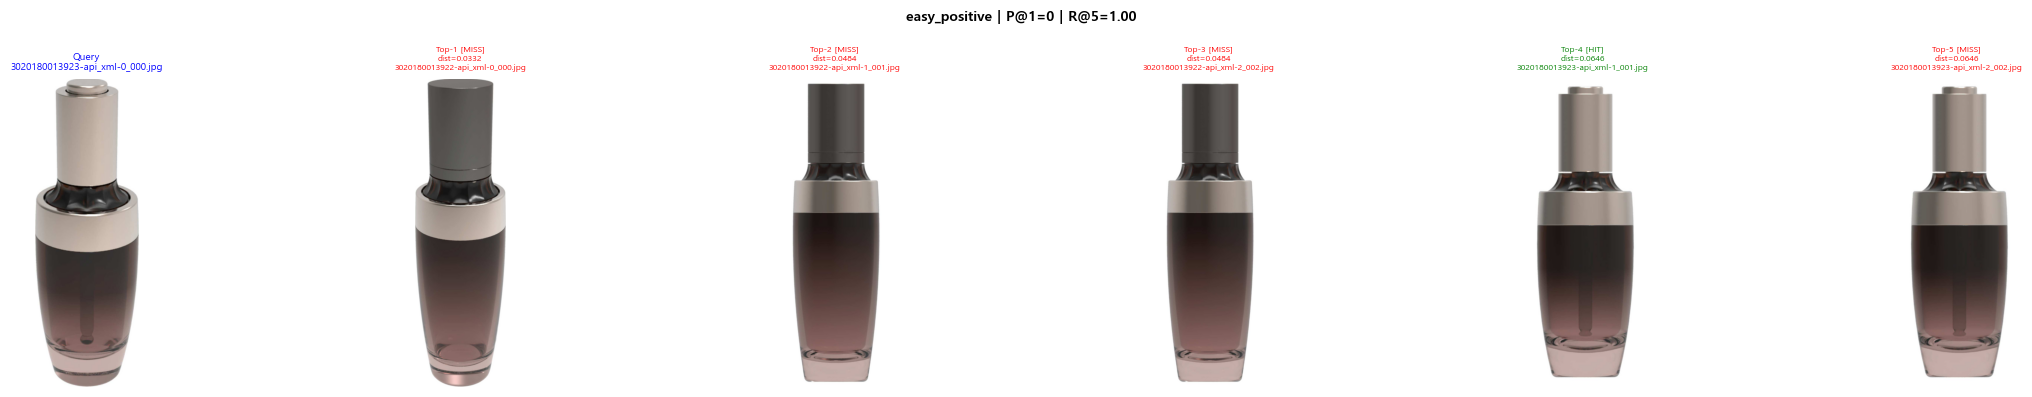

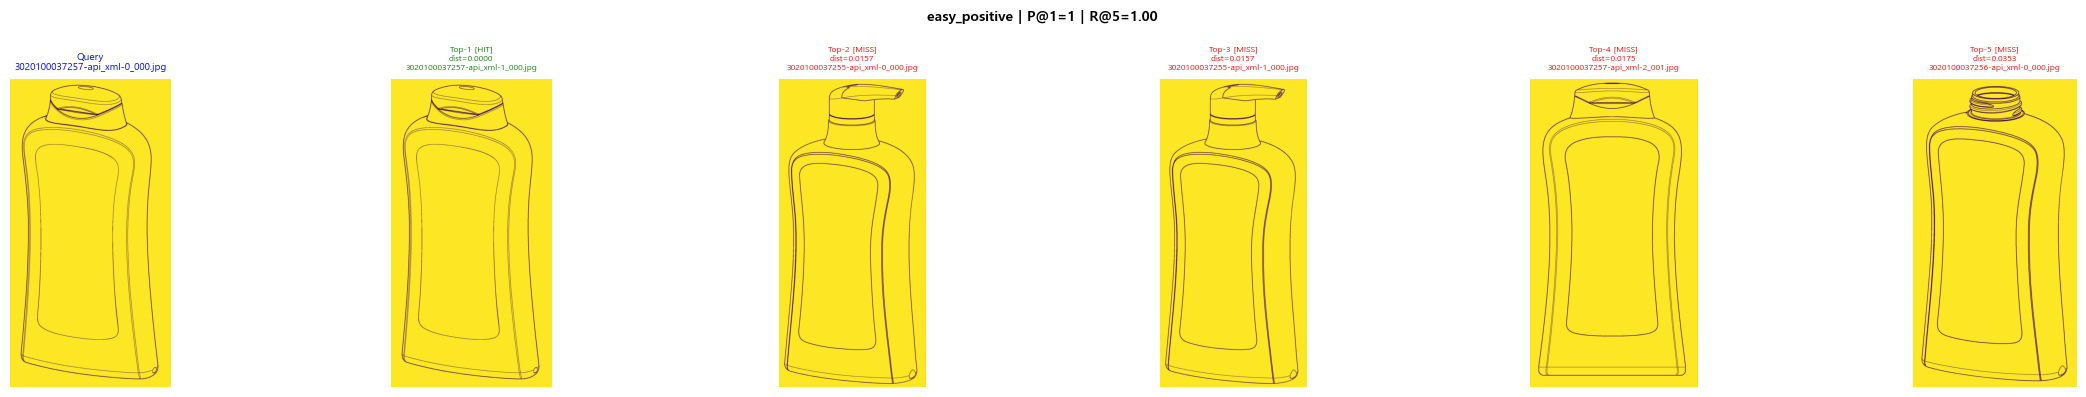

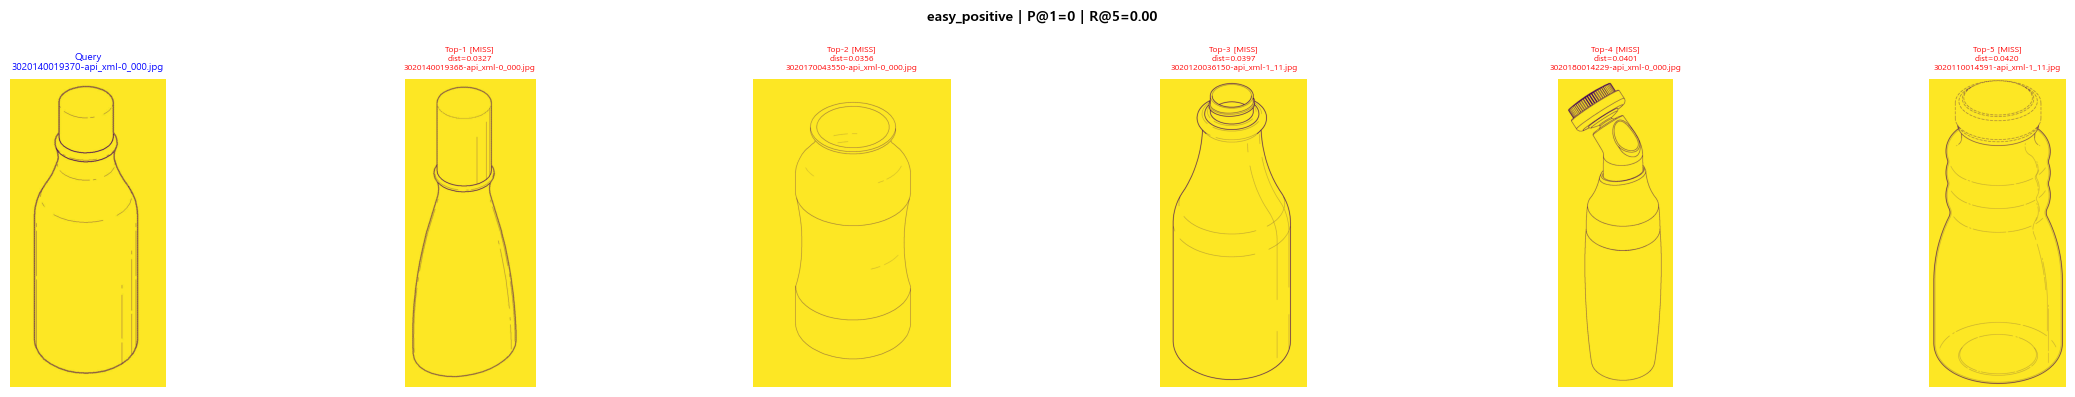

In [17]:
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

for r in results_table:
    fig, axes = plt.subplots(1, 6, figsize=(24, 4))
    
    # 쿼리 이미지
    q_path = os.path.join(IMAGE_DIR, r["query"])
    try:
        axes[0].imshow(Image.open(q_path))
    except:
        axes[0].text(0.5, 0.5, "로드실패", ha='center', va='center')
    axes[0].set_title(f"Query\n{r['query']}", fontsize=7, color='blue')
    axes[0].axis('off')
    
    # Top-5 결과
    relevant_set = query_relevants[r["query"]]
    for j in range(5):
        ax = axes[j + 1]
        if j < len(r["top5"]):
            fname = r["top5"][j]
            dist = r["top5_dist"][j] if j < len(r["top5_dist"]) else None
            is_hit = fname in relevant_set
            
            img_path = os.path.join(IMAGE_DIR, fname)
            try:
                ax.imshow(Image.open(img_path))
            except:
                ax.text(0.5, 0.5, "로드실패", ha='center', va='center')
            
            color = 'green' if is_hit else 'red'
            label = "HIT" if is_hit else "MISS"
            dist_str = f"\ndist={dist:.4f}" if dist else ""
            ax.set_title(f"Top-{j+1} [{label}]{dist_str}\n{fname}", fontsize=6, color=color)
        else:
            ax.text(0.5, 0.5, "없음", ha='center', va='center')
            ax.set_title(f"Top-{j+1}", fontsize=6)
        ax.axis('off')
    
    fig.suptitle(f"{r['type']} | P@1={r['P@1']} | R@5={r['R@5']:.2f}", fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.show()


## 4. 쿼리별 상세 결과 표

## 평가 지표 설명

| 컬럼 | 의미 | 설명 |
|------|------|------|
| `query` | 쿼리 이미지 | 검색에 사용한 이미지 파일명 |
| `type` | 유사도 유형 | `easy_positive`: 같은 출원번호 다른 도면 / `hard_positive`: 같은 출원인&등록일, 다른 출원번호 |
| `n_relevant` | 정답 개수 | 해당 쿼리에 대한 ground truth 정답 이미지 수 |
| `P@1` | Precision@1 | Top-1 결과가 정답이면 1, 아니면 0 |
| `hits@5` | Top-5 적중 수 | Top-5 검색 결과 중 정답에 해당하는 이미지 개수 |
| `R@5` | Recall@5 | 정답 중 Top-5 안에 포함된 비율 (`hits@5 / n_relevant`) |

### Precision@1 vs Recall@5
- **Precision@1**: "가장 유사하다고 반환한 1개가 실제 정답인가?" → 검색 정확도
- **Recall@5**: "전체 정답 중 Top-5 안에 얼마나 포함됐는가?" → 검색 재현율


In [14]:
df = pd.DataFrame(results_table)
df_display = df[["query", "type", "n_relevant", "P@1", "hits@5", "R@5"]].copy()
df_display["R@5"] = df_display["R@5"].map("{:.4f}".format)
df_display

,query,type,n_relevant,P@1,hits@5,R@5
0,3020250019104-api_xml-0_000.jpg,easy_positive,1,0,0,0.0000
1,3020170036338-api_xml-0_000.jpg,easy_positive,1,0,0,0.0000
2,3020170010907-api_xml-0_000.jpg,easy_positive,1,0,0,0.0000
3,3020250017783-api_xml-0_000.jpg,easy_positive,1,0,1,1.0000
4,3020230007555-api_xml-0_000.jpg,easy_positive,1,1,1,1.0000
5,3020110052379-api_xml-0_000.jpg,easy_positive,1,1,1,1.0000
6,3020110050623-api_xml-0_000.jpg,easy_positive,1,1,1,1.0000
7,3020170006416-api_xml-0_000.jpg,easy_positive,1,0,0,0.0000
8,3020170022977-api_xml-0_000.jpg,easy_positive,1,0,0,0.0000
9,3020110039567-api_xml-0_000.jpg,easy_positive,1,1,1,1.0000


## 5. 요약 테이블 (type별 + 전체)

In [15]:
type_stats = defaultdict(lambda: {"total": 0, "p1": 0, "r5": 0.0})
for r in results_table:
    ts = type_stats[r["type"]]
    ts["total"] += 1
    ts["p1"] += r["P@1"]
    ts["r5"] += r["R@5"]

summary_rows = []
for typ, s in type_stats.items():
    summary_rows.append({
        "구분": typ,
        "쿼리수": s["total"],
        "Precision@1": s["p1"] / s["total"] if s["total"] else 0,
        "Recall@5": s["r5"] / s["total"] if s["total"] else 0,
    })

avg_p1 = precision1_hits / total_queries if total_queries else 0
avg_r5 = recall5_sum / total_queries if total_queries else 0
summary_rows.append({
    "구분": "전체",
    "쿼리수": total_queries,
    "Precision@1": avg_p1,
    "Recall@5": avg_r5,
})

df_summary = pd.DataFrame(summary_rows)
df_summary["Precision@1"] = df_summary["Precision@1"].map("{:.4f}".format)
df_summary["Recall@5"] = df_summary["Recall@5"].map("{:.4f}".format)
df_summary

,구분,쿼리수,Precision@1,Recall@5
0,easy_positive,14,0.4286,0.5714
1,전체,14,0.4286,0.5714
